# 🌊 LakeCat Watersheds + NLCD Land Cover — Upper Klamath Lake & Crater Lake, Oregon

## What this notebook does

Everything runs in memory or via HTTP range requests — **no files are downloaded or saved**.The full stack is:

```
EPA S3 (GeoParquet, public)
    ↓  HTTP range requests — only matching row groups transfer
DuckDB (Python)  — ST_AsGeoJSON(geometry) in the query
    ↓  returns GeoJSON geometry strings as a DataFrame
json.loads → GeoJSON FeatureCollection (in memory)
    ↓  m.add_geojson(geojson_str)
GeoLibre widget — full GIS app in the notebook cell
```

### Watersheds and LandUse Summary
| | Upper Klamath Lake | Crater Lake |
|---|---|---|
| **COMID** | `23794487` | `166257594` |
| **HUC2** | 18 | 18 |
| **HUC8** | 18010203 | 18010205 |
| **Watershed area** | ~9,760 km² (sprawling ag/rangeland basin) | ~53 km² (sealed volcanic caldera) |
| **Hydrology** | Major inflows: Williamson R., Wood R. | **No inlets or outlets** — rain + snow  |
| **NLCD signature** | Dominated by shrubland, cropland, pasture | Nearly 100% evergreen forest + water |

Swap in any valid NHDPlusV2 COMIDs and update `HUC2`

## Install

In [ ]:
# [Python]
%pip install --quiet --upgrade duckdb geolibre

## Query StreamCat S3 with DuckDB

DuckDB's `httpfs` extension streams only the Parquet **row groups** that satisfy the `COMID` filter.  

The HUC2 Hive partition (`HUC2=17/`) means DuckDB touches exactly one file rather than globbing all 21 partitions.  
Credentials are intentionally blank — the S3 bucket is fully public.

In [1]:
# [Python]
import duckdb, json
import geopandas as gpd
import pandas as pd

# ── Lake COMIDs (NHDPlusV2 / LakeCat, HUC2=18) ───────────────────────────────
LAKES = {
    120054054: {"name": "Upper Klamath Lake", "huc8": "18010203"},
    24083377:  {"name": "Crater Lake",        "huc8": "18010205"},
}
HUC2       = "18"
S3_PATH    = f"s3://dmap-data-commons-ow/data/streamcat/LakeCatWatersheds/HUC2={HUC2}/*.parquet"
COMID_LIST = ", ".join(str(c) for c in LAKES)

con = duckdb.connect()
con.execute("""
    INSTALL httpfs; LOAD httpfs;
    INSTALL spatial; LOAD spatial;
    SET s3_region            = 'us-east-1';
    SET s3_use_ssl           = true;
    SET s3_url_style         = 'path';
    SET s3_access_key_id     = '';
    SET s3_secret_access_key = '';
    SET s3_session_token     = '';
    SET enable_object_cache  = true;
""")

# ── Step 1: DESCRIBE — see what columns exist ────────────────────────
# From the schema we can see:
#   COMID, GNIS_ID, GNIS_NAME, REACHCODE, HUC2, HUC4, geometry
schema = con.execute(f"""
    DESCRIBE SELECT * FROM read_parquet('{S3_PATH}') LIMIT 0
""").df()
print("Available columns:")
print(schema[["column_name", "column_type"]].to_string(index=False))
print()

# ── Step 2: Query — return WKB bytes for GeoPandas ───────────────────────────
sql = f"""
    SELECT
        COMID,
        GNIS_NAME             AS lake_name,
        REACHCODE,
        ST_AsWKB(geometry)    AS geom_wkb
    FROM   read_parquet('{S3_PATH}')
    WHERE  CAST(COMID AS VARCHAR) IN ({', '.join(f"'{c}'" for c in LAKES)})
"""

raw = con.execute(sql).df()
con.close()
print(f"Rows from DuckDB : {len(raw)}")
print(f"geom_wkb dtype   : {raw['geom_wkb'].dtype}")
print(f"geom_wkb type[0] : {type(raw['geom_wkb'].iloc[0]).__name__}")
print()

# ── Step 3: Build GeoDataFrame — convert bytearray → bytes for Shapely ───────
# DuckDB returns WKB as Python bytearray; Shapely's from_wkb expects bytes.
# .apply(bytes) does the conversion element-wise in one line.
gdf = gpd.GeoDataFrame(
    raw.drop(columns=["geom_wkb"]),
    geometry=gpd.GeoSeries.from_wkb(raw["geom_wkb"].apply(bytes)),
    crs="EPSG:4326",
)

# ── Step 4: Project to EPSG:5070 and calculate watershed area ────────────────
# EPSG:5070 — US Albers Equal Area, course-standard for continental US area.
gdf_albers = gdf.to_crs("EPSG:5070")
gdf["ws_area_sqkm"] = (gdf_albers.geometry.area / 1e6).round(2)

# Add the friendly name from LAKES dict
gdf["name"] = gdf["COMID"].astype(int).map({k: v["name"] for k, v in LAKES.items()})

print(gdf[["COMID", "name", "lake_name", "ws_area_sqkm"]])

# alias so downstream cells still work
df = gdf


Available columns:
      column_name                                                column_type
            COMID                                                    VARCHAR
          GNIS_ID                                                    VARCHAR
        GNIS_NAME                                                    VARCHAR
        REACHCODE                                                    VARCHAR
             HUC2                                                     BIGINT
             HUC4                                                    VARCHAR
__index_level_0__                                                     BIGINT
             bbox STRUCT(xmin DOUBLE, ymin DOUBLE, xmax DOUBLE, ymax DOUBLE)
         geometry                                      GEOMETRY('EPSG:4326')



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows from DuckDB : 2
geom_wkb dtype   : object
geom_wkb type[0] : bytearray

       COMID                name    lake_name  ws_area_sqkm
0   24083377         Crater Lake  Crater Lake         67.35
1  120054054  Upper Klamath Lake                    8872.44


## Assemble a GeoJSON FeatureCollection in memory

GeoLibre's `add_geojson()` accepts a raw GeoJSON string, a dict, or a GeoPandas GeoDataFrame.  

In [2]:
# [Python]
import json as json_mod

features = [
    {
        "type": "Feature",
        "properties": {
            "COMID":        int(str(row["COMID"])),
            "name":         row["name"],
            "lake_name":    row["lake_name"],
            "ws_area_sqkm": float(row["ws_area_sqkm"]),
        },
        "geometry": row["geometry"].__geo_interface__,
    }
    for _, row in gdf.iterrows()
]

fc = {"type": "FeatureCollection", "features": features}

for f in features:
    p = f["properties"]
    print(f"{p['name']:30s}  "
          f"NHD name: {p['lake_name'] or 'n/a'}  "
          f"Watershed: {p['ws_area_sqkm']:,.1f} km²")


Crater Lake                     NHD name: Crater Lake  Watershed: 67.3 km²
Upper Klamath Lake              NHD name:    Watershed: 8,872.4 km²


## Fetch NLCD 2019 land cover metrics from the StreamCat/LakeCat API

The StreamCat API serves pre-computed watershed-scale NLCD proportions for every NHDPlusV2 lake - here we call it directly with `urllib`

In [3]:
# [Python]
import urllib.request, json

# ── StreamCat / LakeCat REST API — NLCD 2019 watershed metrics ───────────────
# Endpoint: https://api.epa.gov/StreamCat/lakes/metrics
#
# Key details from reading the pynhd source (nhdplus_derived.py):
#   • JSON POST body  (not form-encoded, not query params)
#   • metric name  = lowercase stem + year, e.g. "pctconif2019"
#   • aoi          = "ws"  (not "watershed")
#   • response     = {"count": N, "items": [{comid, pctconif2019ws, ...}]}
#   • column names = all lowercase, AOI suffix appended: "pctconif2019ws"

API_URL    = "https://api.epa.gov/StreamCat/lakes/metrics"
COMID_STR  = ",".join(str(c) for c in LAKES)   # "120054054,24083377"

# 16 NLCD land cover stems — same list as lc_get_nlcd() in StreamCatTools R
NLCD_STEMS = [
    "pctmxfst", "pctow",    "pctshrb",  "pcturbhi",
    "pcturblo", "pcturbmd", "pcturbop", "pctwdwet",
    "pctbl",    "pctconif", "pctcrop",  "pctdecid",
    "pctgrs",   "pcthay",   "pcthbwet", "pctice",
]
YEAR       = 2019
METRIC_STR = ",".join(f"{s}{YEAR}" for s in NLCD_STEMS)

# JSON body — this is what pynhd sends internally
payload = {
    "comid": COMID_STR,
    "name":  METRIC_STR,
    "aoi":   "ws",
}

req = urllib.request.Request(
    API_URL,
    data    = json.dumps(payload).encode(),
    method  = "POST",
    headers = {
        "Content-Type": "application/json",
        "User-Agent":   "GISPR-Course/1.0",
        "Accept":       "application/json",
    },
)

with urllib.request.urlopen(req, timeout=30) as r:
    response = json.loads(r.read())

api_data = response["items"]
print(f"Records returned : {len(api_data)}")

nlcd_by_comid = {int(row["comid"]): row for row in api_data}

# Show columns present (sanity check — should be 16+ NLCD Ws columns)
sample     = api_data[0]
nlcd_cols  = [k for k in sample if k not in ("comid", "catareasqkm", "wsareasqkm",
                                               "catpctfull", "wspctfull")]
print(f"NLCD columns returned ({len(nlcd_cols)}):")
print(", ".join(nlcd_cols))


Records returned : 2
NLCD columns returned (16):
pctbl2019ws, pctconif2019ws, pctcrop2019ws, pctdecid2019ws, pctgrs2019ws, pcthay2019ws, pcthbwet2019ws, pctice2019ws, pctmxfst2019ws, pctow2019ws, pctshrb2019ws, pcturbhi2019ws, pcturblo2019ws, pcturbmd2019ws, pcturbop2019ws, pctwdwet2019ws


## Build the comparison chart

The `nlcd_df` DataFrame has one row per COMID and one column per NLCD class (e.g. `PctConif2019Ws`). We pivot to a `{lake_name: {col: pct}}` dict and build a compact HTML pie chart

In [4]:
# [Python]

# ── Map API column names → labels and colors ──────────────────────────────────
# API returns lowercase with year and "ws" suffix: "pctconif2019ws"
NLCD_WS_COLS = {
    f"pctow{YEAR}ws":     ("Open Water",                  "#476BA0"),
    f"pctice{YEAR}ws":    ("Perennial Ice/Snow",           "#D1DDF9"),
    f"pcturbop{YEAR}ws":  ("Developed, Open Space",        "#DDC9C9"),
    f"pcturblo{YEAR}ws":  ("Developed, Low Intensity",     "#D89382"),
    f"pcturbmd{YEAR}ws":  ("Developed, Med Intensity",     "#BC4B12"),
    f"pcturbhi{YEAR}ws":  ("Developed, High Intensity",    "#721000"),
    f"pctbl{YEAR}ws":     ("Barren Land",                  "#B2ADA3"),
    f"pctdecid{YEAR}ws":  ("Deciduous Forest",             "#68AA63"),
    f"pctconif{YEAR}ws":  ("Evergreen Forest",             "#1C6330"),
    f"pctmxfst{YEAR}ws":  ("Mixed Forest",                 "#B5C98E"),
    f"pctshrb{YEAR}ws":   ("Shrub/Scrub",                  "#CCBA7C"),
    f"pctgrs{YEAR}ws":    ("Herbaceous",                   "#E2E2C1"),
    f"pcthay{YEAR}ws":    ("Hay/Pasture",                  "#DBD83D"),
    f"pctcrop{YEAR}ws":   ("Cultivated Crops",             "#AA7028"),
    f"pctwdwet{YEAR}ws":  ("Woody Wetlands",               "#BAD8EA"),
    f"pcthbwet{YEAR}ws":  ("Emergent Herbaceous Wetlands", "#70A3BA"),
}

# ── Build lc_results: {lake_name: {col: pct}} ────────────────────────────────
available_cols = [c for c in NLCD_WS_COLS if c in api_data[0]]

lc_results = {}
for comid, meta in LAKES.items():
    name = meta["name"]
    row  = nlcd_by_comid.get(comid, {})
    metrics = {col: float(row[col]) for col in available_cols if row.get(col) is not None}
    lc_results[name] = metrics
    print(f"\n{name}  (COMID {comid})")
    for col, pct in sorted(metrics.items(), key=lambda x: -x[1])[:6]:
        print(f"  {NLCD_WS_COLS[col][0]:35s} {pct:5.1f}%")


def build_lc_chart_html(lc_results):
    """Horizontal bar chart comparing NLCD watershed land cover for both lakes."""
    lake_names = list(lc_results.keys())
    bar_colors = ["#4b2e83", "#b7a57a"]   # UW Purple, UW Gold

    all_cols = sorted(
        set(col for vals in lc_results.values() for col in vals),
        key=lambda c: -max(v.get(c, 0) for v in lc_results.values())
    )[:12]

    rows = ""
    for col in all_cols:
        label = NLCD_WS_COLS.get(col, (col, "#ccc"))[0]
        rows += (
            f"<tr><td style='padding:2px 8px;font-size:11px;white-space:nowrap'>"
            f"{label}</td>"
        )
        for i, name in enumerate(lake_names):
            pct = lc_results[name].get(col, 0)
            rows += (
                f"<td style='padding:2px 4px;width:130px'>"
                f"<div style='background:{bar_colors[i]};width:{min(pct*1.5,100):.0f}%;"
                f"height:12px;border-radius:2px'></div></td>"
                f"<td style='padding:2px 4px;font-size:10px;color:#555'>{pct:.1f}%</td>"
            )
        rows += "</tr>"

    legend = "".join(
        f"<span style='display:inline-block;width:12px;height:12px;background:{bar_colors[i]};"
        f"margin-right:4px;border-radius:2px'></span>"
        f"<span style='font-size:11px;margin-right:12px'>{name.split()[0]}</span>"
        for i, name in enumerate(lake_names)
    )

    return f"""
    <div style='font-family:sans-serif;background:#fff;padding:10px;border-radius:6px;
                box-shadow:0 1px 4px rgba(0,0,0,.15);max-width:480px'>
      <div style='font-weight:bold;font-size:13px;margin-bottom:6px'>
        NLCD {YEAR} Land Cover — Watershed Comparison</div>
      <div style='margin-bottom:8px'>{legend}</div>
      <table style='border-collapse:collapse;width:100%'>
        <thead><tr>
          <th style='text-align:left;font-size:11px;padding:2px 8px'>Class</th>
          {"".join(
              f"<th colspan='2' style='text-align:left;font-size:11px;color:{bar_colors[i]}'>"
              f"{n.split()[0]} %</th>"
              for i, n in enumerate(lake_names)
          )}
        </tr></thead>
        <tbody>{rows}</tbody>
      </table>
      <div style='font-size:9px;color:#999;margin-top:6px'>
        Source: LakeCat / StreamCat API (EPA) · NLCD {YEAR}</div>
    </div>
    """


chart_html = build_lc_chart_html(lc_results)
print("\nChart built.")



Upper Klamath Lake  (COMID 120054054)
  Evergreen Forest                     58.7%
  Shrub/Scrub                          20.7%
  Emergent Herbaceous Wetlands          8.1%
  Open Water                            3.7%
  Herbaceous                            3.5%
  Hay/Pasture                           2.1%

Crater Lake  (COMID 24083377)
  Open Water                           78.5%
  Shrub/Scrub                          16.2%
  Evergreen Forest                      4.9%
  Herbaceous                            0.1%
  Developed, Med Intensity              0.1%
  Developed, Low Intensity              0.1%

Chart built.


## Visualize in GeoLibre with Pie Chart

Two outputs:
1. **GeoLibre map widget** — watershed polygons with an NLCD land cover loaded as a cloud-optimized geotif
2. **Matplotlib pie chart** — one pie per lake, with the watershed area in the title and a threshold-grouped legend

In [5]:
# [Python]
from geolibre import Map

# ── Verify fc is a FeatureCollection dict ─────────────────────────────────────
assert isinstance(fc, dict) and fc.get("type") == "FeatureCollection", (
    "fc must be a FeatureCollection dict — re-run the geojson cell above"
)
print(f"fc ready: {len(fc['features'])} feature(s)")

# ── Map ───────────────────────────────────────────────────────────────────────
m = Map(center=(-121.9, 42.6), zoom=8)

# Add NLCD as a COG
m.add_cog(
    "https://data.source.coop/giswqs/opengeos/nlcd_2021_land_cover_30m.tif",
    name="NLCD 2021",
)

# Watershed polygons
m.add_geojson(fc, name="LakeCat Watersheds")

m.add_basemap("positron")   # clean light background, good contrast with watershed fill

m


fc ready: 2 feature(s)


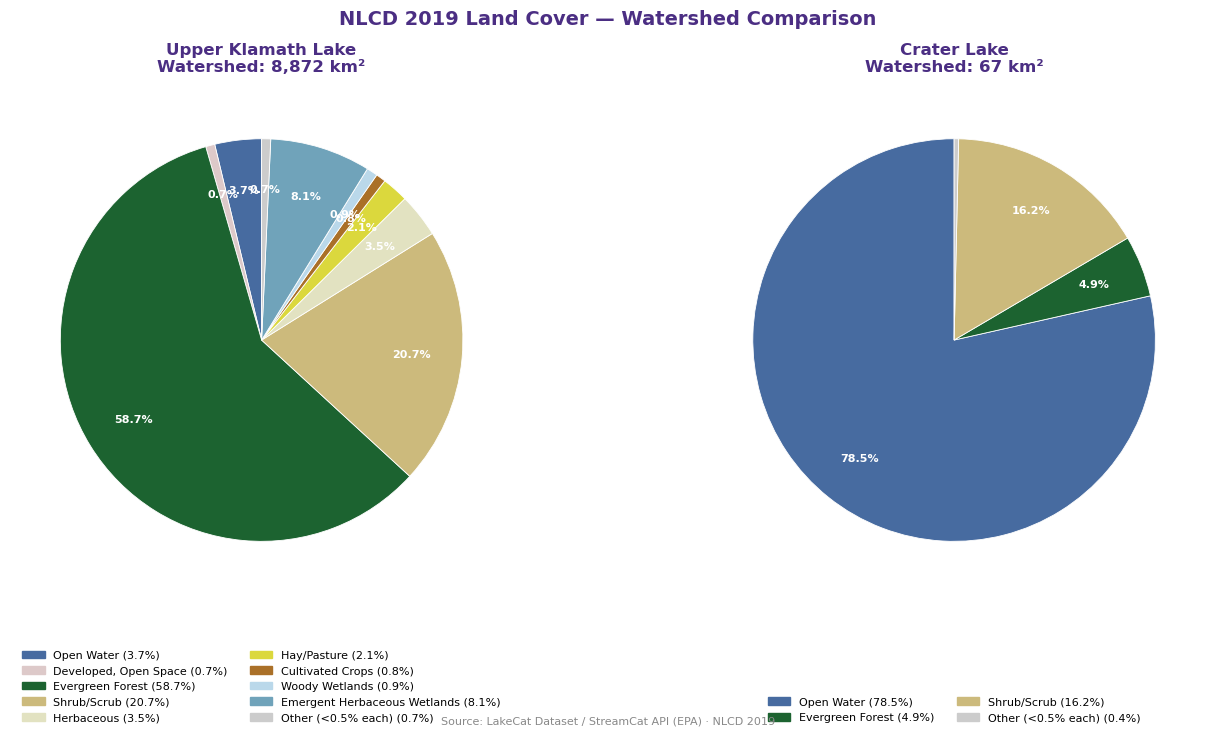

In [6]:
# [Python]
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Pie charts — NLCD 2019 watershed land cover, one per lake ────────────────
# lc_results and NLCD_WS_COLS are built in the cell above.
# We threshold at 0.5% so tiny slivers don't clutter the chart.
THRESHOLD = 0.5   # percent — classes below this are grouped into 'Other'

lake_names = list(lc_results.keys())
fig, axes = plt.subplots(1, len(lake_names), figsize=(7 * len(lake_names), 7))
if len(lake_names) == 1:
    axes = [axes]

for ax, name in zip(axes, lake_names):
    metrics = lc_results[name]

    # Separate above-threshold classes from 'Other'
    above = {col: pct for col, pct in metrics.items() if pct >= THRESHOLD}
    other = sum(pct for pct in metrics.values() if pct < THRESHOLD)

    labels = [NLCD_WS_COLS[col][0] for col in above]
    sizes  = list(above.values())
    colors = [NLCD_WS_COLS[col][1] for col in above]

    if other > 0:
        labels.append(f"Other (<{THRESHOLD}% each)")
        sizes.append(other)
        colors.append("#cccccc")

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=None,          # labels go in the legend, not on wedges
        colors=colors,
        autopct=lambda p: f"{p:.1f}%" if p >= THRESHOLD else "",
        pctdistance=0.75,
        startangle=90,
        wedgeprops={"linewidth": 0.6, "edgecolor": "white"},
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_color("white")
        at.set_fontweight("bold")

    # Legend outside the pie
    legend_patches = [
        mpatches.Patch(color=c, label=f"{l} ({s:.1f}%)")
        for l, s, c in zip(labels, sizes, colors)
    ]
    ax.legend(
        handles=legend_patches,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.28),
        ncol=2,
        fontsize=8,
        frameon=False,
    )

    comid = next(c for c, m in LAKES.items() if m["name"] == name)
    ws_km2 = lc_results[name]   # pcts sum ~100
    ws_area = gdf.loc[gdf["COMID"].astype(str) == str(comid), "ws_area_sqkm"].values
    area_str = f"{ws_area[0]:,.0f} km²" if len(ws_area) else ""
    ax.set_title(
        f"{name}\nWatershed: {area_str}",
        fontsize=12, fontweight="bold",
        color="#4b2e83",   # UW Purple
        pad=12,
    )

fig.suptitle(
    "NLCD 2019 Land Cover — Watershed Comparison",
    fontsize=14, fontweight="bold", color="#4b2e83", y=1.01,
)
plt.figtext(
    0.5, -0.01,
    "Source: LakeCat Dataset / StreamCat API (EPA) · NLCD 2019",
    ha="center", fontsize=8, color="#888888",
)
plt.tight_layout()
plt.show()


> **GeoLibre quick tips**
> - Click a polygon → **Identify** shows `COMID` and any other attributes
> - Bottom-left table icon → **Attribute Table** with filter, sort, export
> - **SQL Workspace** (`Ctrl+Shift+D`) → query the live layer with DuckDB Spatial SQL
> - **Project → Share** → upload to `share.geolibre.app` for a static shareable link

---

## 🔧 Try it yourself

1. Change `COMIDS` to any NHDPlusV2 IDs you find in the [NHD Mapper](https://www.usgs.gov/national-hydrography/access-national-hydrography-products) and re-run cells 1–3
2. Change `HUC2` to `"01"` (New England) and pick COMIDs from that region — notice DuckDB only touches that one partition file
3. Add more attributes to the `SELECT` in cell 1 (e.g. `WsAreaSqKm`, `PctCrop2019Ws`) to enrich the Identify panel
4. In the GeoLibre SQL Workspace, run:  
   ```sql
   SELECT COMID, ST_Area(geometry) AS area_deg2
   FROM "LakeCat Watersheds HUC2-17"
   ORDER BY area_deg2 DESC
   ```

---

## R equivalent (StreamCatTools)

```r
# install.packages("StreamCatTools")  # if needed
library(StreamCatTools)

# Same two features, same HUC2-restricted S3 query
ws <- rbind(
  lc_get_watershed(comid = 23794487,  huc2 = "17"),
  lc_get_watershed(comid = 166257594, huc2 = "17")
)
plot(sf::st_geometry(ws))
```